In [1]:
import os
import sys
current_dir = os.getcwd()
root_path = os.path.abspath(os.path.join(current_dir, '..', '..'))
if root_path not in sys.path:
    sys.path.append(root_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgr_utils import *
from python_scripts.plotting import *
from scipy.special import gammaln
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: False


#### Choose the sgr set you want to use :
* must be data the model did not see at training
* first column : __y_true__ $\in \{0,1\}$ are the samples labels  
* second column : __y_pred__ are the predicted class of samples ($\in \{0,1\}$ too)
* third column : __kappa_f__ is confidence function for each sample, $\in \mathbb{R}_+$

In [2]:
sgr_df = pickle.load(open('sgr_set_cnn','rb')) 
print(sgr_df.shape)
print('Propotion of 1s: ', np.round(sgr_df.y_true.sum()/sgr_df.shape[0],2))
sgr_df.head() 

(40000, 3)
Propotion of 1s:  0.1


,y_true,y_pred,kappa
0,0.0,0.0,0.991906
1,0.0,0.0,0.739398
2,0.0,0.0,0.959858
3,0.0,0.0,0.944551
4,0.0,0.0,0.934431


(optional) choose desired proportion of 1s in train/test datasets for Selective Prediction algos

In [3]:
balance = None # proportion of 1s, None means dataset is not modified
sgr_df = generate_imbalanced_datasets(sgr_df, [balance])[0].sample(frac=1, random_state=0)

In [4]:
delta = 0.001
greedy_search_steps_num = 50 # increase number of search steps for more precise metrics bounds
metric_targets=[i/1000 for i in integers_exp_spacing(5,300)]
proportions_1 = np.linspace(0.01,0.5,15) # for classes imbalance impact study

In [5]:
train_set = sgr_df.iloc[:2*int(len(sgr_df)/3)]
train_set = train_set.sort_values('kappa', ascending=True).reset_index(drop=True).copy()
test_set = sgr_df.iloc[2*int(len(sgr_df)/3):]

## <font color = 'yellow'> 1. __0/1 standard risk control__ 
Dichotomy search for upper bound

#### <font color = 'violet'> 1.1. Risk coverage trade-offs

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.010,0.009840,0.993096,0.005022,0.134403,0.003346,0.134468
1,0.011,0.011279,0.990504,0.006583,0.165192,0.004608,0.162742
2,0.013,0.012858,0.980661,0.008730,0.249156,0.009437,0.246363
3,0.016,0.016031,0.970435,0.011889,0.312270,0.014146,0.307485
4,0.018,0.018068,0.966701,0.013795,0.331658,0.015392,0.326459
5,0.022,0.022021,0.959402,0.017522,0.365972,0.017471,0.360582
6,0.025,0.025096,0.951907,0.020474,0.395635,0.020609,0.389381
7,0.030,0.030064,0.940736,0.025225,0.432611,0.026942,0.431453
8,0.035,0.035070,0.925823,0.030080,0.473749,0.033864,0.476151
9,0.041,0.041041,0.909386,0.035853,0.511475,0.040227,0.514549


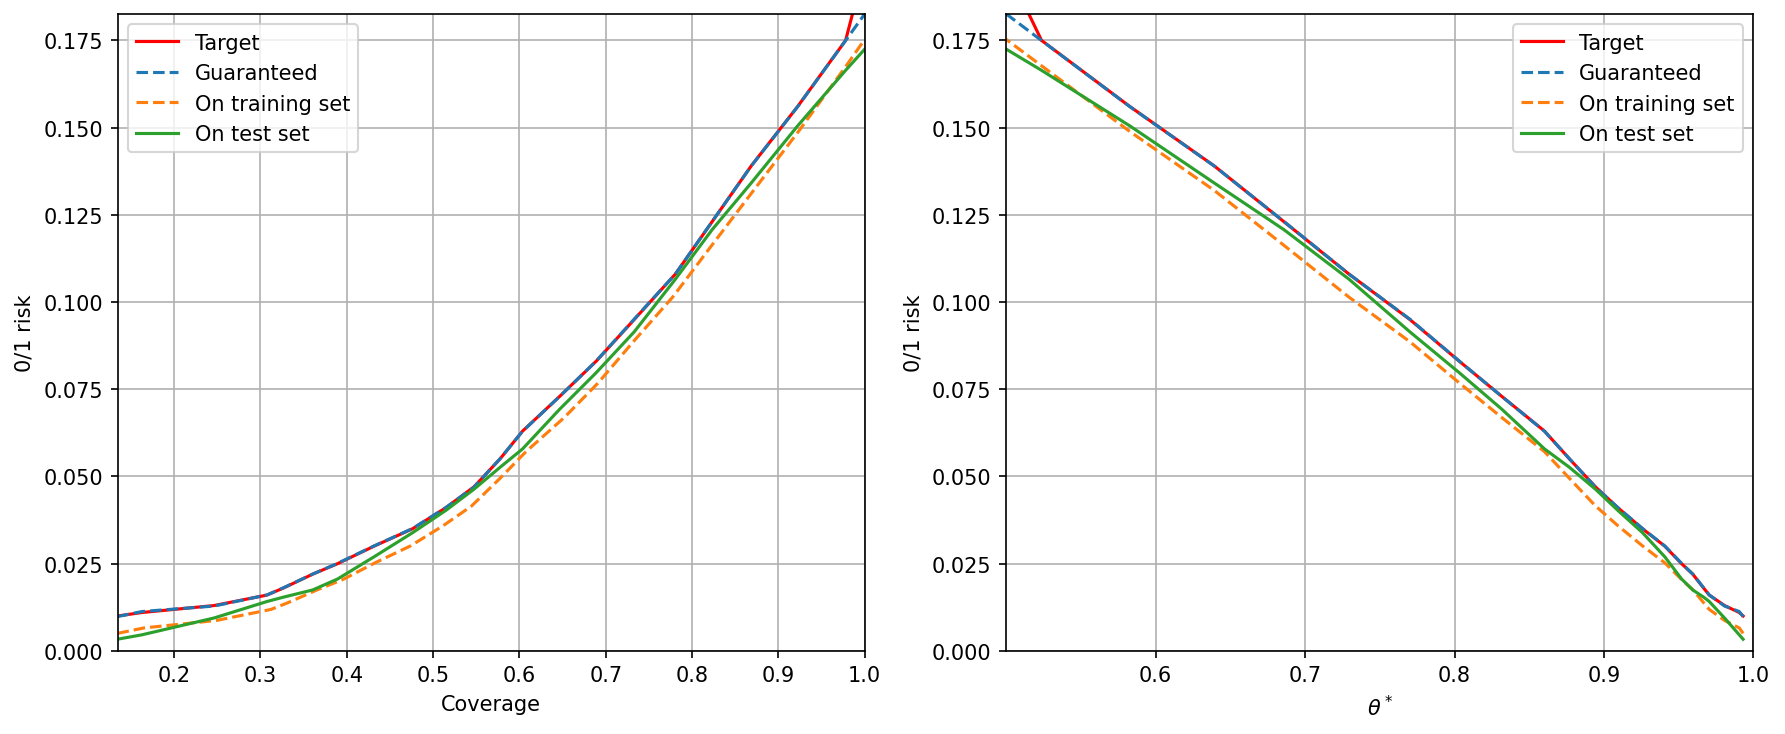

In [6]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, mode='dicho')
display(results)
metric_plots(results, ylabel='0/1 risk', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),1], ylim=[0,max(results.metric_bound)])

__Comment__ : 

At 100% coverage one can observe 1- the classifier accuracy

#### <font color = 'violet'> 1.2. Evolution of trade-offs as class imbalance increases

all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, 
                                                   sgr_df, delta, mode='dicho', 
                                                   metric='standard')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='0/1 risk', xlim1= [min(all_propor_dfs.test_coverage), 1], xlim2= [min(all_propor_dfs.theta_star), 1],
                            ylim=[0,max(all_propor_dfs.metric_bound)], show_left_legend=True)

__Comment__ : here one can observe that
* risk-coverage curves do not really change as class imbalance increases

## <font color = 'yellow'> 2. __FN/FP proportions control__
Dichotomy search for upper bound

### <font color = 'orange'> 2.1. __FP proportion control__

#### <font color = 'violet'> 2.1.1. Risk coverage trade-offs

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.005,0.005211,0.991646,0.001974,0.151991,0.001490,0.151042
1,0.006,0.006229,0.987383,0.003060,0.196092,0.001553,0.193190
2,0.007,0.006854,0.982307,0.003802,0.236706,0.004160,0.234363
3,0.008,0.008105,0.978178,0.004948,0.265244,0.005408,0.263462
4,0.009,0.009026,0.975061,0.005798,0.284595,0.006891,0.282961
5,0.010,0.009960,0.971052,0.006692,0.308220,0.008640,0.303810
6,0.011,0.010898,0.969278,0.007529,0.318758,0.009790,0.314084
7,0.013,0.013062,0.965822,0.009464,0.336796,0.010450,0.330133
8,0.016,0.016057,0.957639,0.012256,0.373284,0.011637,0.367332
9,0.018,0.017979,0.952125,0.014063,0.394660,0.014462,0.388931


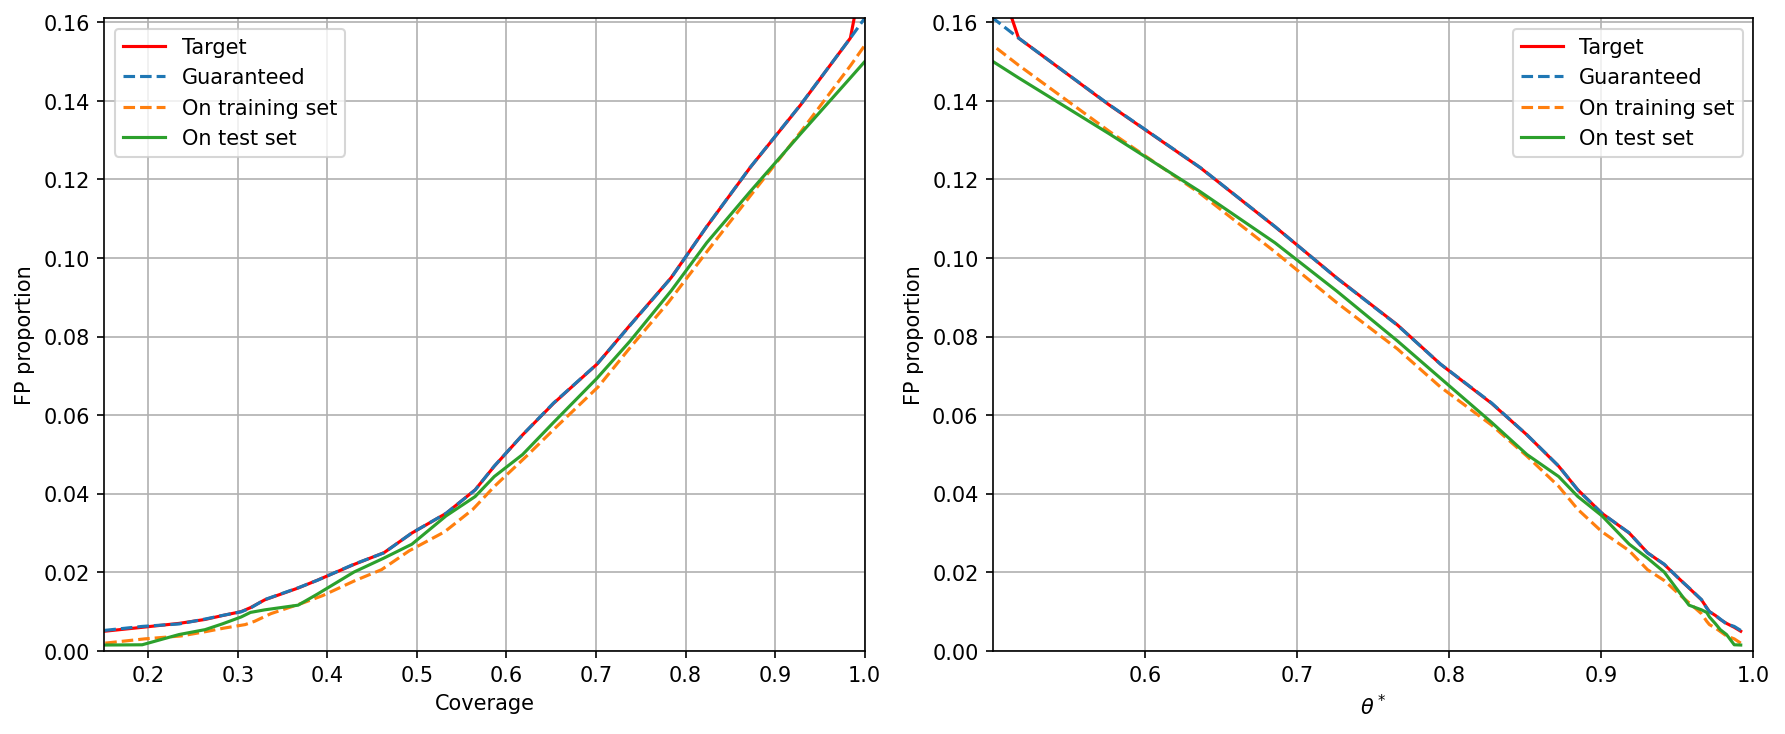

In [7]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric='FP', mode='dicho')
display(results)
metric_plots(results, ylabel='FP proportion', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),1], ylim=[0,max(results.metric_bound)])

__Comment__ : ~threefold increase of performance at the cost of -70% coverage
1) Best guaranteed performance (left) is ~2% of samples classified as FPs, cost is coverage =30%.
2) Baseline performance of classifier at 100% coverage would be ~10% of samples classified as FPs.

#### <font color = 'violet'> 2.1.2 Evolution of trade-offs as class imbalance increases

all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, sgr_df, 
                                                   delta, mode='dicho', metric='FP')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='FP proportion', xlim1= [min(all_propor_dfs.test_coverage), 1], xlim2= [min(all_propor_dfs.theta_star), 1],
                            ylim=[0,max(all_propor_dfs.metric_bound)], show_left_legend=True)

__Comment__ : one can observe that here less 1s means
* higher FP risk at fixed coverage (makes completely sense since there are relatively more 0s to commit mistakes on)
* steeper risk/coverage curves, ie more FP risk improvement from the same amount of coverage renouncement

__In other words, in this setting, higher class imbalance => Selection with Guaranteed FP Risk brings more benefits with the same amount of coverage renouncement__

### <font color = 'orange'> 2.2. __FN proportion control__

#### <font color = 'violet'> 2.2.1. Risk coverage trade-offs

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.008,0.008042,0.965871,0.005237,0.336571,0.005225,0.330133
1,0.009,0.009048,0.960989,0.006159,0.359259,0.005511,0.353832
2,0.010,0.009936,0.932290,0.007234,0.456161,0.007697,0.457927
3,0.011,0.011081,0.916906,0.008336,0.494862,0.008744,0.497450
4,0.013,0.012949,0.854864,0.010280,0.616478,0.011371,0.613394
5,0.016,0.015978,0.753186,0.013285,0.750881,0.014893,0.755362
6,0.018,0.018033,0.678864,0.015310,0.830346,0.016908,0.829459
7,0.022,0.021985,0.555233,0.019171,0.948736,0.020975,0.947503
8,0.025,0.024055,0.500022,0.021189,0.999962,0.022499,1.000000
9,0.030,0.024055,0.500022,0.021189,0.999962,0.022499,1.000000


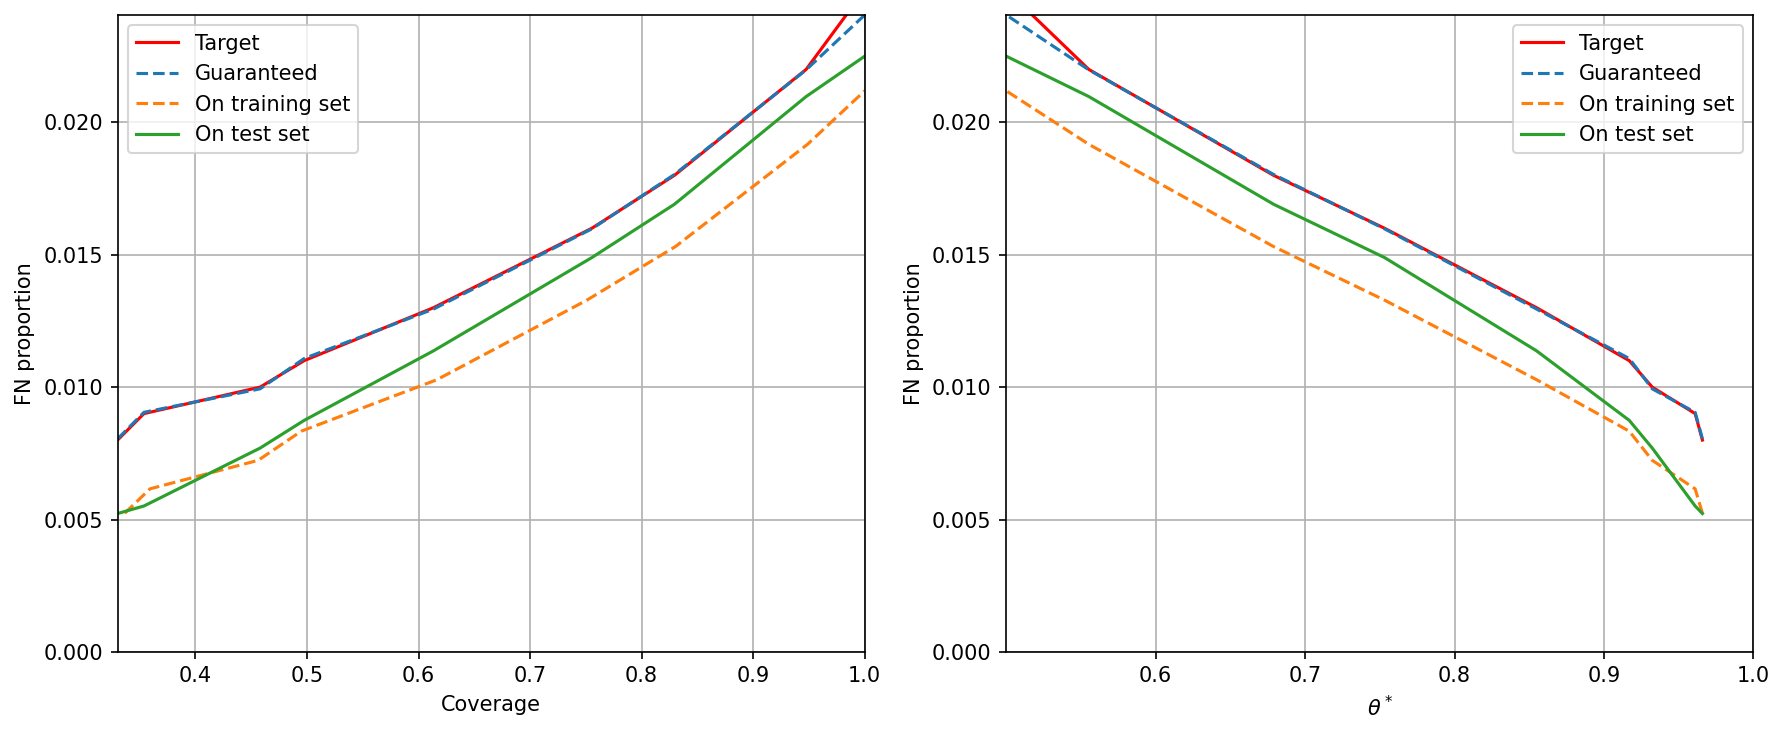

In [8]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'FN', mode='dicho')
display(results)
metric_plots(results, ylabel='FN proportion', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),1], ylim=[0,max(results.metric_bound)])

#### <font color = 'violet'> 2.2.2 Evolution of trade-offs as class imbalance increases

all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, sgr_df,
                                                   delta, mode='dicho', metric='FN')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='FN proportion', xlim1= [min(all_propor_dfs.test_coverage), 1], xlim2= [min(all_propor_dfs.theta_star), 1],
                            ylim=[0,max(all_propor_dfs.metric_bound)], show_left_legend=True)

## <font color = 'yellow'> __3. Conditional metrics control__

### <font color = 'orange'> 3.1. __FPR control__

#### <font color = 'violet'> 3.1.1. Risk coverage trade-offs

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.007,0.006648,0.989787,0.002661,0.172504,0.001342,0.170991
1,0.008,0.006648,0.989787,0.002661,0.172504,0.001342,0.170991
2,0.009,0.008514,0.979584,0.004704,0.256244,0.005500,0.254012
3,0.010,0.008514,0.979584,0.004704,0.256244,0.005500,0.254012
4,0.011,0.008514,0.979584,0.004704,0.256244,0.005500,0.254012
5,0.013,0.012141,0.969380,0.007921,0.318120,0.010003,0.313784
6,0.016,0.012141,0.969380,0.007921,0.318120,0.010003,0.313784
7,0.018,0.017132,0.959176,0.012327,0.367097,0.012265,0.361557
8,0.022,0.021888,0.948973,0.016604,0.406060,0.017683,0.401380
9,0.025,0.021888,0.948973,0.016604,0.406060,0.017683,0.401380


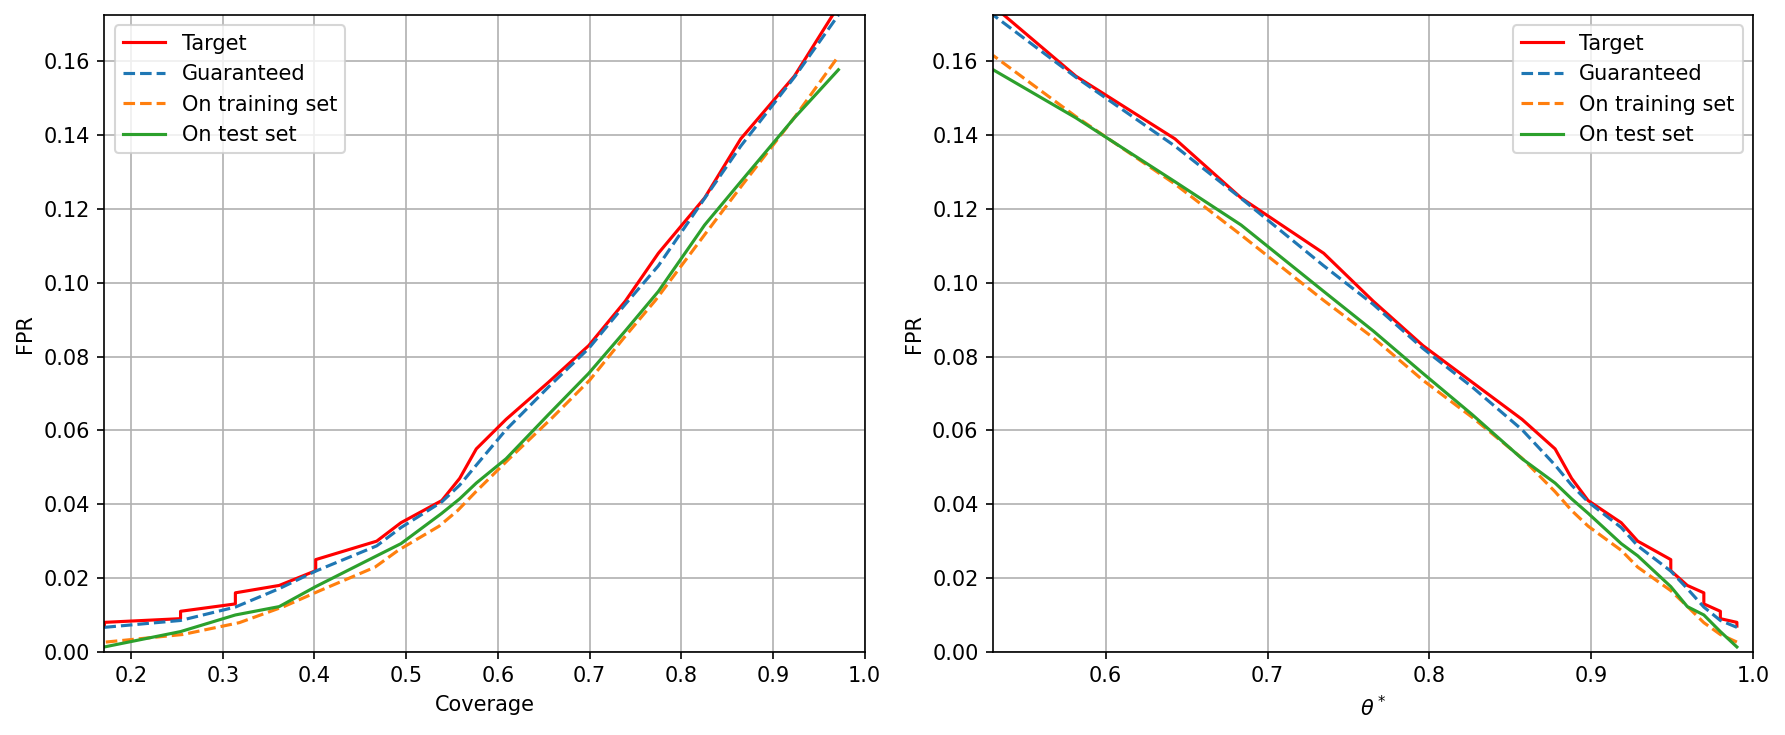

In [9]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'FPR', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='FPR', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),1], ylim=[0,max(results.metric_bound)])

#### <font color = 'violet'> 3.1.2. Evolution of trade-offs as class imbalance increases

all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, 
                                                   sgr_df, delta, mode='greedy',
                                                   greedy_search_steps_num=greedy_search_steps_num, 
                                                   metric='FPR')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='FPR', xlim1= [min(all_propor_dfs.test_coverage), 1], xlim2= [min(all_propor_dfs.theta_star), 1],
                            ylim=[0,max(all_propor_dfs.metric_bound)], show_left_legend=True)

### <font color = 'orange'> 3.2. __FNR control__

#### <font color = 'violet'> 3.2.1. Risk coverage trade-offs

,metric_target,metric_bound,theta_star,train_metric,train_coverage,test_metric,test_coverage
0,0.219,0.218209,0.775511,0.135640,0.725456,0.156571,0.725589
1,0.244,0.241271,0.653068,0.164653,0.857196,0.180313,0.856232
2,0.271,0.268466,0.561236,0.191939,0.943036,0.213529,0.941653
3,0.300,0.296686,0.938769,0.098321,0.438498,0.103896,0.437828


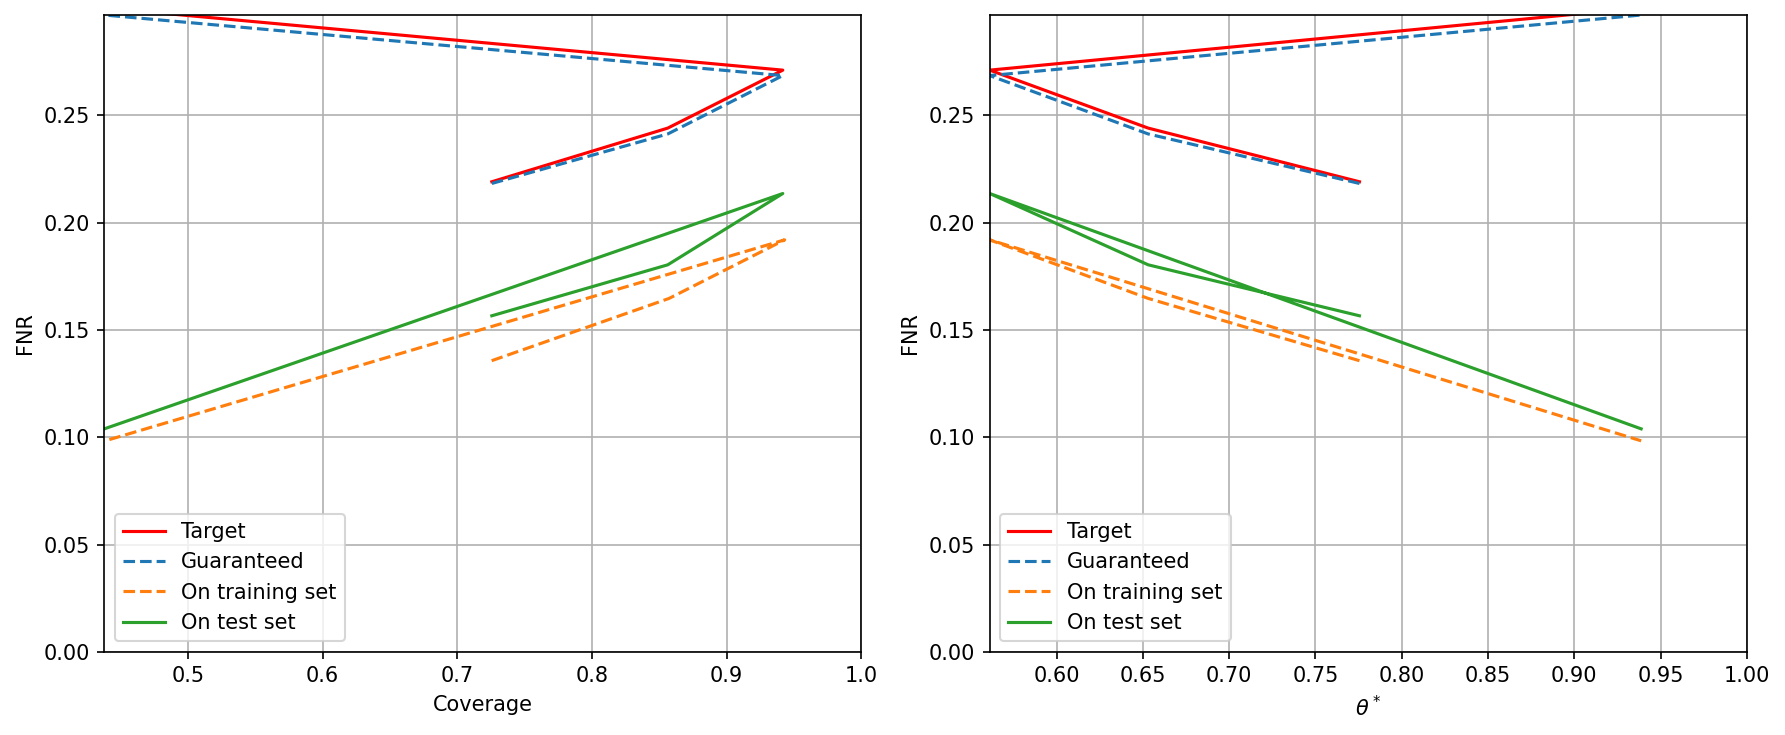

In [10]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'FNR', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='FNR', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),1], ylim=[0,max(results.metric_bound)])

#### <font color = 'violet'> 3.2.2. Evolution of trade-offs as class imbalance increases

all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, 
                                                   sgr_df, delta, mode='greedy',
                                                   greedy_search_steps_num=greedy_search_steps_num,
                                                   metric='FNR')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='FNR', xlim1= [min(all_propor_dfs.test_coverage), 1], xlim2= [min(all_propor_dfs.theta_star), 1],
                            ylim=[0,max(all_propor_dfs.metric_bound)], show_left_legend=True)

### <font color = 'orange'> 3.3. __PPV control__

#### <font color = 'violet'> 3.3.1. Risk coverage trade-offs

In [11]:
metric_targets=[i/1000 for i in integers_log_spacing(700,1000)]

In [13]:
results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'PPV', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='PPV', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),1], ylim=[0.8, max(results.train_metric)])

KeyboardInterrupt: 

#### <font color = 'violet'> 3.3.2. Evolution of trade-offs as class imbalance increases

all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, 
                                                   sgr_df, delta, mode='greedy',
                                                   greedy_search_steps_num=greedy_search_steps_num,
                                                   metric='PPV')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='PPV', xlim1= [min(all_propor_dfs.test_coverage), 1], xlim2= [min(all_propor_dfs.theta_star), 1],
                            ylim=[min(all_propor_dfs.metric_bound),max(all_propor_dfs.test_metric)], show_left_legend=True)

### <font color = 'orange'> 3.4. __SE control__

#### <font color = 'violet'> 3.4.1. Risk coverage trade-offs

results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'SE', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='SE', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),1], ylim=[0.8,max(results.train_metric)])

#### <font color = 'violet'> 3.4.2. Evolution of trade-offs as class imbalance increases

all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, 
                                                   sgr_df, delta, mode='greedy',
                                                   greedy_search_steps_num=greedy_search_steps_num,
                                                   metric='SE')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='SE', xlim1= [min(all_propor_dfs.test_coverage), 1], xlim2= [min(all_propor_dfs.theta_star), 1],
                            ylim=[min(all_propor_dfs.metric_bound),max(all_propor_dfs.test_metric)],
                            show_left_legend=True)

### <font color = 'orange'> 3.5. __SP control__

#### <font color = 'violet'> 3.5.1. Risk coverage trade-offs

results = SGR_at_targets(train_set, test_set, k=int(np.log2(train_set.shape[0])),
                         delta=delta, metric_targets=metric_targets, 
                         metric = 'SP', mode='greedy', steps=greedy_search_steps_num)
display(results)
metric_plots(results, ylabel='SP', xlim1=[min(results.test_coverage),1], xlim2=[min(results.theta_star),1], ylim=[0.8,max(results.train_metric)])

#### <font color = 'violet'> 3.5.2. Evolution of trade-offs as class imbalance increases

all_propor_dfs = SGR_at_targets_on_imbalanced_sets(proportions_1, metric_targets, 
                                                   sgr_df, delta, mode='greedy',
                                                   greedy_search_steps_num=greedy_search_steps_num,
                                                   metric='SP')
metric_plots_with_imbalance(all_propor_dfs, proportions_1,
                            ylabel='SP', xlim1= [min(all_propor_dfs.test_coverage), 1], xlim2= [min(all_propor_dfs.theta_star), 1],
                            ylim=[0.8,max(all_propor_dfs.test_metric)], show_left_legend=True)